# Equity Research Notebook

## Libraries

In [1]:
import wrds
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
from scipy.stats import linregress
from scipy.optimize import minimize

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

## Tickers

In [2]:

#tickers = ['COP', 'EOG', 'OXY', 'FANG', 'EQT', 'TPL', 'DVN', 'CTRA', 'EXE', 'APA', 'NEE', 'SO', 'DUK', 'AEP', 'D', 'XEL', 'EXC', 'ETR', 'PEG', 'ED', 'PCG', 'WEC', 'DTE', 'AEE', 'FE', 'PPL', 'CNP', 'EIX', 'ES', 'CMS', 'EVRG', 'LNT', 'PNW']

# PRIVATE PORTFOLIO
tickers = ["WELL", "HWM", "PM", "NEM", "DUOL", "NFLX", "IREN",  "TPL", "EQT", "EVRG", "AEP", "DELL"]


# TICKER FILTER 
#tickers = ['INCY', 'FSLR', 'APH', 'FOXA', 'VTR', 'META', 'ES', 'RF', 'SPG', 'HCA', 'BK', 'RTX', 'ABBV', 'DELL', 'BKNG', 'KEY', 'CSCO', 'MPWR', 'EIX', 'CFG', 'ALL', 'MCK', 'D', 'DGX', 'COF', 'HLT', 'GD', 'AIZ', 'TRV', 'HIG', 'ACGL', 'GL', 'WEC', 'WELL', 'CCL', 'TEL', 'NEE', 'BLK', 'PLD', 'ULTA', 'PODD', 'IBM', 'L', 'T', 'DVN', 'LDOS', 'UHS', 'CB', 'MTB', 'SYF', 'ROK', 'DAL', 'STT', 'USB', 'PKG', 'LUV', 'JCI', 'EVRG', 'LH', 'HST']

# S&P 500 (Available ticker)
#tickers = ["MMM","AOS","ABT","ABBV","ACN","ADBE","AMD","AES","AFL","A","APD","AKAM","ALK","ALB","ARE","ALLE","LNT","ALL","GOOGL","GOOG","MO","AMZN","AMCR","AEE","AAL","AEP","AXP","AIG","AMT","AWK","AMP","AME","AMGN","APH","ADI","AON","APA","AAPL","AMAT","APTV","ACGL","ADM","ANET","AJG","AIZ","T","ATO","ADSK","ADP","AZO","AVB","AVY","AXON","BKR","BALL","BAC","BBWI","BAX","BDX","BBY","BIO","TECH","BIIB","BLK","BX","BK","BA","BKNG","BWA","BSX","BMY","AVGO","BR","BRO","BLDR","BG","BXP","CHRW","CDNS","CZR","CPT","CPB","COF","CAH","KMX","CCL","CARR","CAT","CBOE","CBRE","CDW","CE","COR","CNC","CNP","CF","CRL","SCHW","CHTR","CVX","CMG","CB","CHD","CI","CINF","CTAS","CSCO","C","CFG","CLX","CME","CMS","KO","CTSH","CL","CMCSA","CAG","COP","ED","STZ","CEG","COO","CPRT","GLW","CPAY","CTVA","CSGP","COST","CTRA","CRWD","CCI","CSX","CMI","CVS","DHR","DRI","DVA","DAY","DECK","DE","DELL","DAL","DVN","DXCM","FANG","DLR","DG","DLTR","D","DPZ","DOV","DOW","DHI","DTE","DUK","DD","EMN","ETN","EBAY","ECL","EIX","EW","EA","ELV","EMR","ENPH","ETR","EOG","EPAM","EQT","EFX","EQIX","EQR","ESS","EL","EG","EVRG","ES","EXC","EXPE","EXPD","EXR","XOM","FFIV","FDS","FICO","FAST","FRT","FDX","FIS","FITB","FSLR","FE","FMC","F","FTNT","FTV","FOXA","FOX","BEN","FCX","GRMN","IT","GE","GEHC","GEV","GEN","GNRC","GD","GIS","GM","GPC","GILD","GPN","GL","GDDY","GS","HAL","HIG","HAS","HCA","DOC","HSIC","HSY","HPE","HLT","HOLX","HD","HON","HRL","HST","HWM","HPQ","HUBB","HUM","HBAN","HII","IBM","IEX","IDXX","ITW","INCY","IR","PODD","INTC","ICE","IFF","IP","INTU","ISRG","IVZ","INVH","IQV","IRM","JBHT","JBL","JKHY","J","JNJ","JCI","JPM","KVUE","KDP","KEY","KEYS","KMB","KIM","KMI","KKR","KLAC","KHC","KR","LHX","LH","LRCX","LW","LVS","LDOS","LEN","LIN","LYV","LKQ","LMT","L","LOW","LULU","LYB","MTB","MPC","MKTX","MAR","MLM","MAS","MA","MTCH","MKC","MCD","MCK","MDT","MRK","META","MET","MTD","MGM","MCHP","MU","MSFT","MAA","MRNA","MHK","MOH","TAP","MDLZ","MPWR","MNST","MCO","MS","MOS","MSI","MSCI","NDAQ","NTAP","NFLX","NEM","NWSA","NWS","NEE","NKE","NI","NDSN","NSC","NTRS","NOC","NCLH","NRG","NUE","NVDA","NVR","NXPI","ORLY","OXY","ODFL","OMC","ON","OKE","ORCL","OTIS","PCAR","PKG","PLTR","PANW","PH","PAYX","PAYC","PYPL","PNR","PEP","PFE","PCG","PM","PSX","PNW","PNC","POOL","PPG","PPL","PFG","PG","PGR","PLD","PRU","PEG","PTC","PSA","PHM","QRVO","PWR","QCOM","DGX","RL","RJF","RTX","O","REG","REGN","RF","RSG","RMD","RVTY","ROK","ROL","ROP","ROST","RCL","SPGI","CRM","SBAC","SLB","STX","SRE","NOW","SHW","SPG","SWKS","SJM","SW","SNA","SOLV","SO","LUV","SWK","SBUX","STT","STLD","STE","SYK","SMCI","SYF","SNPS","SYY","TMUS","TROW","TTWO","TPR","TRGP","TGT","TEL","TDY","TFX","TER","TSLA","TXN","TPL","TXT","TMO","TJX","TSCO","TT","TDG","TRV","TRMB","TFC","TYL","TSN","USB","UBER","UDR","ULTA","UNP","UAL","UPS","URI","UNH","UHS","VLO","VTR","VLTO","VRSN","VRSK","VZ","VRTX","VTRS","VICI","V","VST","VMC","WRB","WAB","WMT","DIS","WBD","WM","WAT","WEC","WFC","WELL","WST","WDC","WY","WMB","WTW","WYNN","XEL","XYL","YUM","ZBRA","ZBH","ZTS"]

# UTILITIES
#tickers = ['NEE', 'SO', 'DUK', 'AEP', 'D', 'XEL', 'EXC', 'ETR', 'PEG', 'ED', 'PCG', 'WEC', 'DTE', 'AEE', 'FE', 'PPL', 'CNP', 'EIX', 'ES', 'CMS', 'EVRG', 'LNT', 'PNW']

# ENERGY OIL & GAS
#tickers = ['COP', 'EOG', 'OXY', 'FANG', 'EQT', 'TPL', 'DVN', 'CTRA', 'EXE', 'APA']

## Analysis Configuration

In [3]:
start_year = 2020
weight_cap = 0.25
interval = '1d'

macro_factors = ['^VIX', 'GC=F', '^TNX']
treasury_yield = '^FVX'
market_index = '^GSPC'

if interval == '1d':
    assume_trading_days = 252
elif interval == '1wk':
    assume_trading_days = 52
elif interval == '1mo':
    assume_trading_days = 12

console_formating = 180

## Analysis Toggle

In [4]:
MARKET_TABLE = True
PORTFOLIO_TABLE = True
COMPS_TABLE = True
FUNDAMENTALS_TABLE = True

MACRO_TABLE = False
HIST_MULTIPLES_TABLE = False
COMPS_SECTOR_MEDIAN_TABLE = False
EFFICIENT_FRONTIER = False
SHOW_PAIRPLOT = False

TICKERS_FILTER = True

## Table Format Function

In [5]:
def _styled_table(df, include_index_column=True):
    table_df = df.copy()

    # Keep meaningful index labels as a visible first column (e.g., ticker names).
    if include_index_column and not isinstance(table_df.index, pd.RangeIndex):
        idx_name = table_df.index.name if table_df.index.name else 'Index'
        table_df = table_df.reset_index().rename(columns={'index': idx_name})

    styler = (
        table_df.style
        .hide(axis='index')
        .set_table_styles([
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
            {'selector': 'thead th', 'props': [('background-color', '#0f0f10'), ('color', '#f5f5f5'), ('font-weight', '800'), ('font-size', '15px'), ('padding', '10px 12px'), ('border-bottom', '2px solid #3a3a3a')]},
            {'selector': 'tbody td', 'props': [('font-size', '14px'), ('padding', '9px 12px'), ('border', 'none'), ('color', '#f0f0f0')]},
            {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#171717')]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#2b2b2b')]}
        ])
    )

    display(styler)


def _print_df_with_bars(df):
    _styled_table(df, include_index_column=True)

## Fetch Market Data and Calculate Returns 

In [6]:
today = dt.datetime.today()
end = today - dt.timedelta(days=1)
start = dt.datetime(start_year, 1, 1)
price_tickers = [market_index] + tickers

df_prices = yf.download(price_tickers, start=start, end=end, interval=interval, auto_adjust=False).dropna()

rf_data = yf.download(treasury_yield, start=start, end=end, interval=interval, auto_adjust=False)['Adj Close']
if isinstance(rf_data, pd.DataFrame):
    rf_data = rf_data.squeeze('columns')
rf_series = pd.to_numeric(rf_data, errors='coerce').dropna()

if rf_series.empty and treasury_yield != '^TNX':
    rf_fallback = yf.download('^TNX', start=start, end=end, interval=interval, auto_adjust=False)['Adj Close']
    if isinstance(rf_fallback, pd.DataFrame):
        rf_fallback = rf_fallback.squeeze('columns')
    rf_series = pd.to_numeric(rf_fallback, errors='coerce').dropna()

if rf_series.empty:
    print(f"[RF] No valid treasury yield data for {treasury_yield} (or fallback). Using 0.0%.")
    rf_annual = 0.0
else:
    rf_annual = float(rf_series.iloc[-1]) / 100

rf = rf_annual / assume_trading_days

df_log_returns = np.log(df_prices['Adj Close']).diff().dropna()
df_mean_returns = df_log_returns.mean()
df_variance_returns = df_log_returns.var()
df_stdev_returns = df_log_returns.std()

index_returns = df_log_returns[market_index]
beta_dict = {}
alpha_dict = {}

for stock in tickers:
    stock_returns = df_log_returns[stock]
    excess_market = index_returns - rf
    excess_stock = stock_returns - rf
    slope, intercept, r_value, p_value, std_err = linregress(excess_market, excess_stock)
    beta_dict[stock] = slope
    alpha_dict[stock] = intercept

annual_mean_returns = np.exp(df_mean_returns * assume_trading_days) - 1
annual_variance_returns = df_variance_returns * assume_trading_days
annual_stdev_returns = df_stdev_returns * np.sqrt(assume_trading_days)
annual_alpha_dict = {stock: alpha * assume_trading_days for stock, alpha in alpha_dict.items()}
annual_capm_dict = {stock: rf + beta_dict[stock] * (annual_mean_returns[market_index] - rf) for stock in beta_dict.keys()}

stock_tickers = tickers.copy()
df_stock_returns = df_log_returns[stock_tickers]
excess_returns = df_stock_returns - df_stock_returns.mean()
n_obs = len(excess_returns)
variance_covariance_matrix = (excess_returns.T @ excess_returns) / (n_obs - 1)
annualized_variance_covariance_matrix = variance_covariance_matrix * assume_trading_days
correlation_matrix = df_stock_returns.corr()

try:
    df_macro_prices = yf.download(macro_factors, start=start, end=end, interval=interval, auto_adjust=False).dropna()
except Exception:
    df_macro_prices = pd.DataFrame()

if not df_macro_prices.empty:
    df_macro_returns = np.log(df_macro_prices['Adj Close']).diff().dropna()
else:
    df_macro_returns = pd.DataFrame()

if not df_macro_returns.empty:
    combined_returns = pd.concat([df_stock_returns, df_macro_returns], axis=1)
    correlation_macro = combined_returns.corr().loc[stock_tickers, macro_factors]
    correlation_macro.columns = ['VIX', 'Gold', 'Interest']
else:
    correlation_macro = pd.DataFrame(index=stock_tickers, columns=['VIX', 'Gold', 'Interest'])

[*********************100%***********************]  13 of 13 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  3 of 3 completed


## Modern Portfolio Theory

In [7]:
def portfolio_variance(weights, cov_matrix):
    return weights @ cov_matrix @ weights

def negative_sharpe_ratio(weights, returns, cov_matrix, risk_free_rate):
    port_return = np.sum(weights * returns)
    port_variance = weights @ cov_matrix @ weights
    port_sd = np.sqrt(port_variance)
    sharpe = (port_return - risk_free_rate) / port_sd if port_sd != 0 else 0
    return -sharpe

def least_correlation_objective(weights, corr_matrix):
    return weights @ corr_matrix @ weights

def negative_return(weights, returns):
    return -np.sum(weights * returns)

annualized_returns = np.array([annual_mean_returns[ticker] for ticker in stock_tickers])
initial_weights = np.array([1 / len(stock_tickers)] * len(stock_tickers))
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, weight_cap) for _ in stock_tickers)

result = minimize(
    portfolio_variance,
    initial_weights,
    args=(annualized_variance_covariance_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

min_var_weights = result.x
min_var_portfolio_variance = result.fun
min_var_portfolio_sd = np.sqrt(min_var_portfolio_variance)
min_var_portfolio_return = np.sum(min_var_weights * annualized_returns)
min_var_sharpe_ratio = (min_var_portfolio_return - rf) / min_var_portfolio_sd if min_var_portfolio_sd != 0 else 0

min_var_df = pd.DataFrame({
    'Stock': stock_tickers,
    'Weight': min_var_weights,
    'var(P)': min_var_portfolio_variance,
    'SD(P)': min_var_portfolio_sd,
    'E[R_P]': min_var_portfolio_return,
    'S_P': min_var_sharpe_ratio
}).set_index('Stock')

result_tangent = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(annualized_returns, annualized_variance_covariance_matrix, rf),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

tangent_weights = result_tangent.x
tangent_portfolio_variance = tangent_weights @ annualized_variance_covariance_matrix @ tangent_weights
tangent_portfolio_sd = np.sqrt(tangent_portfolio_variance)
tangent_portfolio_return = np.sum(tangent_weights * annualized_returns)
tangent_sharpe_ratio = (tangent_portfolio_return - rf) / tangent_portfolio_sd if tangent_portfolio_sd != 0 else 0

tangent_port_df = pd.DataFrame({
    'Stock': stock_tickers,
    'Weight': tangent_weights,
    'var(P)': tangent_portfolio_variance,
    'SD(P)': tangent_portfolio_sd,
    'E[R_P]': tangent_portfolio_return,
    'S_P': tangent_sharpe_ratio
}).set_index('Stock')

result_least_corr = minimize(
    least_correlation_objective,
    initial_weights,
    args=(correlation_matrix.values,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

least_corr_weights = result_least_corr.x
least_corr_portfolio_corr = least_correlation_objective(least_corr_weights, correlation_matrix.values)
least_corr_portfolio_return = np.sum(least_corr_weights * annualized_returns)
least_corr_portfolio_variance = least_corr_weights @ annualized_variance_covariance_matrix @ least_corr_weights
least_corr_portfolio_sd = np.sqrt(least_corr_portfolio_variance)
least_corr_sharpe_ratio = (least_corr_portfolio_return - rf) / least_corr_portfolio_sd if least_corr_portfolio_sd != 0 else 0

least_corr_df = pd.DataFrame({
    'Stock': stock_tickers,
    'Weight': least_corr_weights,
    'Corr(P)': least_corr_portfolio_corr,
    'E[R_P]': least_corr_portfolio_return,
    'var(P)': least_corr_portfolio_variance,
    'SD(P)': least_corr_portfolio_sd,
    'S_P': least_corr_sharpe_ratio
}).set_index('Stock')

result_max_return = minimize(
    negative_return,
    initial_weights,
    args=(annualized_returns,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

max_return_weights = result_max_return.x
max_return_portfolio_return = np.sum(max_return_weights * annualized_returns)
max_return_portfolio_variance = max_return_weights @ annualized_variance_covariance_matrix @ max_return_weights
max_return_portfolio_sd = np.sqrt(max_return_portfolio_variance)
max_return_sharpe_ratio = (max_return_portfolio_return - rf) / max_return_portfolio_sd if max_return_portfolio_sd != 0 else 0

max_return_df = pd.DataFrame({
    'Stock': stock_tickers,
    'Weight': max_return_weights,
    'E[R_P]': max_return_portfolio_return,
    'var(P)': max_return_portfolio_variance,
    'SD(P)': max_return_portfolio_sd,
    'S_P': max_return_sharpe_ratio
}).set_index('Stock')

## Calculate Market Metrics

In [8]:
def _get_price_on_or_after(series, dt_obj):
    s = series[series.index >= pd.Timestamp(dt_obj)]
    return s.iloc[0] if not s.empty else series.iloc[0]

total_returns = {stock: (df_prices['Adj Close'][stock].iloc[-1] / df_prices['Adj Close'][stock].iloc[0]) - 1 for stock in stock_tickers}
market_total_return = (df_prices['Adj Close'][market_index].iloc[-1] / df_prices['Adj Close'][market_index].iloc[0]) - 1

start_of_year = dt.datetime(today.year, 1, 1)
ytd_returns = {}
for ticker in stock_tickers:
    series = df_prices['Adj Close'][ticker]
    start_price = _get_price_on_or_after(series, start_of_year)
    ytd_returns[ticker] = (series.iloc[-1] / start_price) - 1

market_start_price = _get_price_on_or_after(df_prices['Adj Close'][market_index], start_of_year)
market_ytd_return = (df_prices['Adj Close'][market_index].iloc[-1] / market_start_price) - 1

latest_prices = {}
market_caps = {}
sector_map = {}
low_52w = {}
high_52w = {}
for ticker in stock_tickers:
    latest_prices[ticker] = df_prices['Adj Close'][ticker].iloc[-1]
    try:
        info = yf.Ticker(ticker).info
        market_caps[ticker] = info.get('marketCap', np.nan)
        sector_map[ticker] = info.get('sector', 'N/A')
        low_52w[ticker] = info.get('fiftyTwoWeekLow', np.nan)
        high_52w[ticker] = info.get('fiftyTwoWeekHigh', np.nan)
    except Exception:
        market_caps[ticker] = np.nan
        sector_map[ticker] = 'N/A'
        low_52w[ticker] = np.nan
        high_52w[ticker] = np.nan

total_market_cap = sum(v for v in market_caps.values() if not pd.isna(v)) if len(market_caps) > 0 else np.nan

summary_data = [{
    'Ticker': 'S&P500',
    'Sector': 'Index',
    'Total Return (%)': market_total_return * 100,
    'YTD Return (%)': market_ytd_return * 100,
    'Mean Return (%)': annual_mean_returns[market_index] * 100,
    'σ (%)': annual_stdev_returns[market_index] * 100,
    'Sharpe Ratio': (annual_mean_returns[market_index] - rf) / annual_stdev_returns[market_index] if annual_stdev_returns[market_index] != 0 else 0,
    'β': 1.0,
    'CAPM (%)': annual_mean_returns[market_index] * 100,
    'α (%)': 0,
    'Market Price': df_prices['Adj Close'][market_index].iloc[-1],
    '52W Low': np.nan,
    '52W High': np.nan,
    'MC ($B)': (total_market_cap / 1e9) if not pd.isna(total_market_cap) else np.nan,
    'MC Proportion (%)': 100.0
}]

# Table
for stock in stock_tickers:
    mcap = market_caps.get(stock, np.nan)
    pct = (mcap / total_market_cap * 100) if (not pd.isna(mcap) and total_market_cap and total_market_cap > 0) else np.nan
    summary_data.append({
        'Ticker': stock,
        'Sector': sector_map.get(stock, 'N/A'),
        'Total Return (%)': total_returns[stock] * 100,
        'YTD Return (%)': ytd_returns.get(stock, np.nan) * 100,
        'Mean Return (%)': annual_mean_returns[stock] * 100,
        'σ (%)': annual_stdev_returns[stock] * 100,
        'Sharpe Ratio': (annual_mean_returns[stock] - rf) / annual_stdev_returns[stock] if annual_stdev_returns[stock] != 0 else 0,
        'β': beta_dict[stock],
        'CAPM (%)': annual_capm_dict[stock] * 100,
        'α (%)': annual_alpha_dict[stock] * 100,
        'Market Price': latest_prices.get(stock, np.nan),
        '52W Low': low_52w.get(stock, np.nan),
        '52W High': high_52w.get(stock, np.nan),
        'MC ($B)': (mcap / 1e9) if not pd.isna(mcap) else np.nan,
        'MC Proportion (%)': pct
    })

summary_df = pd.DataFrame(summary_data).set_index('Ticker')

summary_df['PT'] = np.nan
summary_df['ΔPT (%)'] = np.nan

## Calculate Normaliezed Returns for Plot

In [9]:
required_vars = ['df_stock_returns', 'stock_tickers', 'df_prices', 'df_macro_prices', 'market_index', 'np', 'pd']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing required variables: {missing}. "
        "Run the setup/market-data cells before normalized return calculations."
    )

if df_prices is None or df_prices.empty:
    raise ValueError('`df_prices` is empty. No market index data available.')
if df_macro_prices is None or df_macro_prices.empty:
    raise ValueError('`df_macro_prices` is empty. No macro data available.')

# Build 3M normalized macro panel: Index + VIX + Gold + Interest
if isinstance(df_prices.columns, pd.MultiIndex):
    index_close = df_prices['Adj Close'][market_index].copy()
else:
    index_close = df_prices[market_index].copy()

macro_targets = ['^VIX', 'GC=F', '^TNX']
if isinstance(df_macro_prices.columns, pd.MultiIndex):
    macro_adj = df_macro_prices['Adj Close']
    missing_macro = [s for s in macro_targets if s not in macro_adj.columns]
    if missing_macro:
        raise KeyError(f'Missing macro symbols in df_macro_prices Adj Close: {missing_macro}')
    macro_close = macro_adj[macro_targets].copy()
else:
    missing_macro = [s for s in macro_targets if s not in df_macro_prices.columns]
    if missing_macro:
        raise KeyError(f'Missing macro symbols in df_macro_prices: {missing_macro}')
    macro_close = df_macro_prices[macro_targets].copy()

macro_3m_frame = pd.concat([index_close, macro_close], axis=1).dropna()
if macro_3m_frame.empty:
    raise ValueError('No overlapping observations between index and macro series.')

end_date = macro_3m_frame.index.max()
start_date = end_date - pd.DateOffset(months=3)
macro_3m = macro_3m_frame.loc[macro_3m_frame.index >= start_date].copy()
if macro_3m.empty:
    raise ValueError('No observations available in the last 3 months.')

normalized_returns_3m = macro_3m / macro_3m.iloc[0]
normalized_returns_3m.columns = [
    f'{market_index} (normalized)',
    'VIX (normalized)',
    'Gold (normalized)',
    'Interest (normalized)'
]

if 'weekly_returns_pct' not in globals() or weekly_returns_pct is None or weekly_returns_pct.empty:
    weekly_returns_pct = (df_stock_returns.resample('W-FRI').sum().dropna() * 100)

plot_cols = [t for t in stock_tickers if t in weekly_returns_pct.columns]
plot_df = weekly_returns_pct[plot_cols].dropna(how='all')
if plot_df.empty:
    raise ValueError('No weekly return observations available for plotting.')

q_lo = plot_df.quantile(0.01)
q_hi = plot_df.quantile(0.99)
plot_df_hist = plot_df.clip(lower=q_lo, upper=q_hi, axis=1)

x_bound = float(max(abs(plot_df_hist.min().min()), abs(plot_df_hist.max().max())))
x_bound = max(5.0, x_bound)

daily_plot_cols = [t for t in stock_tickers if t in df_stock_returns.columns]
daily_returns_plot = df_stock_returns[daily_plot_cols].dropna(how='all')
if daily_returns_plot.empty:
    raise ValueError('No daily return observations available for normalized return plot.')

if isinstance(df_prices.columns, pd.MultiIndex):
    ticker_prices = df_prices['Adj Close'][daily_plot_cols].dropna(how='all')
else:
    ticker_prices = df_prices[daily_plot_cols].dropna(how='all')

ticker_prices_3m = ticker_prices.loc[ticker_prices.index >= start_date].dropna(how='all')
if ticker_prices_3m.empty:
    raise ValueError('No daily price observations available for 3-month ticker normalized plot.')

normalized_returns_tickers_3m = ticker_prices_3m.div(ticker_prices_3m.iloc[0])
normalized_returns = np.exp(daily_returns_plot.cumsum())

## Fetch WRDS Data

In [10]:
conn = wrds.Connection(wrds_username='tobiasnhh')  # create pgpass file for automated login

def fetch_wrds_price_targets(connection, selected_tickers):
    if not selected_tickers:
        return pd.DataFrame(columns=['tic', 'price_target', 'target_date', 'source'])

    normalized_tickers = sorted({str(t).upper().strip() for t in selected_tickers if str(t).strip()})
    ticker_sql = ', '.join(["'{}'".format(t.replace("'", "''")) for t in normalized_tickers])

    query_attempts = [
        f"""
            SELECT UPPER(TRIM(oftic)) AS tic,
                   statpers AS target_date,
                   meanptg AS price_target
            FROM ibes.ptgsum
            WHERE UPPER(TRIM(oftic)) IN ({ticker_sql})
              AND meanptg IS NOT NULL
              AND usfirm = 1
              AND measure = 'PTG'
            ORDER BY oftic, statpers DESC
        """,
        f"""
            SELECT UPPER(TRIM(oftic)) AS tic,
                   actdats AS target_date,
                   value AS price_target
            FROM ibes.ptgdet
            WHERE UPPER(TRIM(oftic)) IN ({ticker_sql})
              AND value IS NOT NULL
              AND usfirm = 1
              AND measure = 'PTG'
              AND horizon = 12
            ORDER BY oftic, actdats DESC
        """
    ]

    for idx, query in enumerate(query_attempts, start=1):
        try:
            pt_data = connection.raw_sql(query)
            if pt_data is None or pt_data.empty:
                print(f'[WRDS PT] Query {idx} returned no rows.')
                continue

            pt_data = pt_data.copy()
            pt_data['tic'] = pt_data['tic'].astype(str).str.upper().str.strip()
            pt_data['target_date'] = pd.to_datetime(pt_data['target_date'], errors='coerce')
            pt_data['price_target'] = pd.to_numeric(pt_data['price_target'], errors='coerce')
            pt_data['source'] = 'ibes.ptgsum' if idx == 1 else 'ibes.ptgdet'
            pt_data = pt_data.dropna(subset=['tic', 'price_target']).sort_values(['tic', 'target_date'], ascending=[True, False])
            pt_data = pt_data.drop_duplicates(subset=['tic'], keep='first')

            missing_tickers = sorted(set(normalized_tickers) - set(pt_data['tic'].unique()))
            if missing_tickers:
                print(f"[WRDS PT] Missing targets for: {', '.join(missing_tickers)}")

            return pt_data[['tic', 'price_target', 'target_date', 'source']]
        except Exception as exc:
            print(f'[WRDS PT] Query {idx} failed: {exc}')
            continue

    return pd.DataFrame(columns=['tic', 'price_target', 'target_date', 'source'])

gvkeys = conn.raw_sql(f"""
    SELECT DISTINCT gvkey, tic
    FROM comp.funda
    WHERE tic IN {tuple(tickers)}
""")

gvkey_list = tuple(gvkeys.gvkey.unique())

data = conn.raw_sql(f"""
    SELECT gvkey, tic, datadate, fyear,
        sale, ebit, ni, csho,
        oancf,
        dltt, dlc, ceq
    FROM comp.funda
    WHERE gvkey IN {gvkey_list}
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear >= {start_year - 1}
    ORDER BY gvkey, fyear
""")

data['datadate'] = pd.to_datetime(data['datadate'], errors='coerce')
data = data[data['datadate'].notna()]
data = data[data['datadate'] <= pd.Timestamp.today()]
data = data.sort_values(['tic', 'datadate'])

data['Revenue_Growth'] = data.groupby('tic')['sale'].pct_change(fill_method=None)
data['EBIT_Margin'] = data['ebit'] / data['sale']

_csho = pd.to_numeric(data['csho'], errors='coerce')
data['EPS'] = np.where(_csho.fillna(0) > 0, data['ni'] / _csho, np.nan)
data['EPS_Growth'] = data.groupby('tic')['EPS'].pct_change(fill_method=None)

data['OCF_Growth'] = data.groupby('tic')['oancf'].pct_change(fill_method=None)
data['OCF_Margin'] = data['oancf'] / data['sale']

data['Debt_to_Equity'] = (data['dltt'] + data['dlc']) / data['ceq']

def default_rating(x):
    if pd.isna(x):
        return 'Risky'
    elif x > 0.247:
        return 'Aaa'
    elif x > 0.188:
        return 'Aa'
    elif x > 0.142:
        return 'A'
    elif x > 0.128:
        return 'Baa'
    elif x > 0.118:
        return 'Ba'
    elif x > 0.095:
        return 'B'
    elif x > 0.045:
        return 'C'
    else:
        return 'Risky'

data['Default_Risk'] = data['EBIT_Margin'].apply(default_rating)
data['Revenue'] = data['sale']
data['EBIT'] = data['ebit']
data['OCF'] = data['oancf']
data['Debt'] = data['dltt'] + data['dlc']
data['Equity'] = data['ceq']
data = data[data['fyear'] >= start_year]

metrics = ['Revenue_Growth', 'EBIT_Margin', 'EPS_Growth', 'OCF_Growth', 'OCF_Margin', 'Debt_to_Equity', 'Default_Risk', 'Revenue', 'EBIT', 'EPS', 'OCF', 'Debt', 'Equity']
final = data[['tic', 'fyear'] + metrics].copy().sort_values(['tic', 'fyear']).set_index(['tic', 'fyear'])

Loading library list...
Done


## Calculate Historical Multiples and COMPS

In [11]:
def _get_latest_non_null(series):
    s = series.dropna()
    return s.iloc[-1] if not s.empty else np.nan

price_long = df_prices['Adj Close'][stock_tickers].copy().stack().reset_index()
price_long.columns = ['date', 'tic', 'price']
price_long['date'] = pd.to_datetime(price_long['date'], errors='coerce')
price_long['tic'] = price_long['tic'].astype(str)
price_long = price_long.dropna(subset=['date', 'tic', 'price']).sort_values(['tic', 'date'])

fund_cols_for_merge = ['tic', 'datadate', 'sale', 'ebit', 'ni', 'csho', 'dltt', 'dlc']
fund_pt = data[fund_cols_for_merge].copy().sort_values(['tic', 'datadate'])
fund_pt['tic'] = fund_pt['tic'].astype(str)

merged_frames = []
for ticker in stock_tickers:
    price_t = price_long[price_long['tic'] == ticker].sort_values('date')
    fund_t = fund_pt[fund_pt['tic'] == ticker].sort_values('datadate').drop(columns=['tic'])
    if price_t.empty or fund_t.empty:
        continue
    merged_t = pd.merge_asof(price_t, fund_t, left_on='date', right_on='datadate', direction='backward')
    merged_t['tic'] = ticker
    merged_frames.append(merged_t)

historical_multiples = pd.concat(merged_frames, ignore_index=True) if merged_frames else pd.DataFrame(columns=['date', 'tic', 'price', 'datadate', 'sale', 'ebit', 'ni', 'csho', 'dltt', 'dlc'])
historical_multiples = historical_multiples.dropna(subset=['sale', 'ebit', 'ni', 'csho'])

historical_multiples['EPS'] = np.where(historical_multiples['csho'] > 0, historical_multiples['ni'] / historical_multiples['csho'], np.nan)
historical_multiples['P/E'] = np.where(historical_multiples['EPS'] > 0, historical_multiples['price'] / historical_multiples['EPS'], np.nan)

historical_multiples['shares'] = historical_multiples['csho'] * 1e6
historical_multiples['market_cap'] = historical_multiples['price'] * historical_multiples['shares']
historical_multiples['total_debt'] = (historical_multiples['dltt'] + historical_multiples['dlc']) * 1e6
historical_multiples['enterprise_value'] = historical_multiples['market_cap'] + historical_multiples['total_debt']

historical_multiples['EV/Sales'] = np.where(historical_multiples['sale'] > 0, historical_multiples['enterprise_value'] / (historical_multiples['sale'] * 1e6), np.nan)
historical_multiples['EV/EBIT'] = np.where(historical_multiples['ebit'] > 0, historical_multiples['enterprise_value'] / (historical_multiples['ebit'] * 1e6), np.nan)

sector_map = {}
for ticker in stock_tickers:
    try:
        sector_map[ticker] = yf.Ticker(ticker).info.get('sector', 'N/A')
    except Exception:
        sector_map[ticker] = 'N/A'

historical_multiples['Sector'] = historical_multiples['tic'].map(sector_map).fillna('N/A')

hist_start = pd.Timestamp(dt.datetime(today.year - 1, 1, 1))
historical_multiples = historical_multiples[historical_multiples['date'] >= hist_start]

historical_multiples_summary = pd.DataFrame()

if not historical_multiples_summary.empty:
    industry_avg = historical_multiples_summary.groupby('Sector')[['P/E_Current', 'EV/Sales_Current', 'EV/EBIT_Current']].mean().rename(columns={
        'P/E_Current': 'P/E_Industry',
        'EV/Sales_Current': 'EV/Sales_Industry',
        'EV/EBIT_Current': 'EV/EBIT_Industry'
    })

    historical_multiples_summary = historical_multiples_summary.merge(industry_avg, left_on='Sector', right_index=True, how='left')
    historical_multiples_summary['P/E_Price'] = historical_multiples_summary['P/E_Industry'] * historical_multiples_summary['EPS_Current']

    implied_ev_sales = historical_multiples_summary['EV/Sales_Industry'] * historical_multiples_summary['Revenue_Current']
    implied_equity_sales = implied_ev_sales - historical_multiples_summary['Debt_Current']
    historical_multiples_summary['EV/Sales_Price'] = np.where(
        historical_multiples_summary['Shares_Current'] > 0,
        implied_equity_sales / historical_multiples_summary['Shares_Current'],
        np.nan
    )

    implied_ev_ebit = historical_multiples_summary['EV/EBIT_Industry'] * historical_multiples_summary['EBIT_Current']
    implied_equity_ebit = implied_ev_ebit - historical_multiples_summary['Debt_Current']
    historical_multiples_summary['EV/EBIT_Price'] = np.where(
        historical_multiples_summary['Shares_Current'] > 0,
        implied_equity_ebit / historical_multiples_summary['Shares_Current'],
        np.nan
    )



wrds_price_targets = fetch_wrds_price_targets(conn, stock_tickers)
wrds_target_map = wrds_price_targets.set_index('tic')['price_target'].to_dict() if not wrds_price_targets.empty else {}

summary_df.loc[:, 'PT'] = np.nan
summary_df.loc[:, 'ΔPT (%)'] = np.nan

for stock in stock_tickers:
    pt_value = wrds_target_map.get(stock)
    latest_price = latest_prices.get(stock, np.nan)
    summary_df.loc[stock, 'PT'] = pt_value if pt_value is not None else np.nan
    if pt_value is not None and not pd.isna(latest_price) and latest_price > 0:
        summary_df.loc[stock, 'ΔPT (%)'] = ((pt_value / latest_price) - 1) * 100

summary_col_order = ['Sector', 'MC Proportion (%)', 'Market Price', 'PT', 'ΔPT (%)', '52W Low', '52W High', 'YTD Return (%)', 'Total Return (%)', 'Mean Return (%)', 'σ (%)', 'β', 'Sharpe Ratio', 'α (%)']
summary_df = summary_df[summary_col_order]

pd.options.display.float_format = '{:.2%}'.format

## Calculate COMPS

In [12]:
latest_fundamentals = data.loc[data.groupby('tic')['datadate'].idxmax()].copy()

comps_data = []
for stock in stock_tickers:
    firm = latest_fundamentals[latest_fundamentals['tic'] == stock]
    if firm.empty:
        continue
    firm = firm.iloc[0]

    try:
        sector = yf.Ticker(stock).info.get('sector', 'N/A')
    except Exception:
        sector = 'N/A'

    revenue = firm['sale'] * 1e6
    ebit = firm['ebit'] * 1e6
    net_income = firm['ni'] * 1e6
    total_debt = (firm['dltt'] + firm['dlc']) * 1e6

    price = latest_prices.get(stock, np.nan)
    market_cap = market_caps.get(stock, np.nan)

    if pd.isna(price) or pd.isna(market_cap):
        continue

    enterprise_value = market_cap + total_debt
    shares = market_cap / price if price > 0 else np.nan

    pe = (price / (net_income / shares)) if shares and net_income > 0 else np.nan
    ev_sales = enterprise_value / revenue if revenue > 0 else np.nan
    ev_ebit = enterprise_value / ebit if ebit > 0 else np.nan

    comps_data.append({
        'Company': stock,
        'Sector': sector,
        'P/E': pe,
        'EV/Sales': ev_sales,
        'EV/EBIT': ev_ebit
    })

comps_numeric = pd.DataFrame(comps_data).set_index('Company')

industry_median = comps_numeric.groupby('Sector')[['P/E', 'EV/Sales', 'EV/EBIT']].median().round(2)

def add_signal(row, column):
    value = row[column]
    median = industry_median.loc[row['Sector'], column]
    if pd.isna(value) or pd.isna(median):
        return ''
    elif value > median:
        return ' (^) '
    elif value < median:
        return ' (⌄) '
    else:
        return ''

comps_display = comps_numeric.copy()
for col in ['P/E', 'EV/Sales', 'EV/EBIT']:
    comps_display[col] = comps_numeric.apply(
        lambda row: f"{round(row[col],2)}{add_signal(row,col)}" if not pd.isna(row[col]) else np.nan,
        axis=1
    )

def add_price_signal(ticker, implied_price):
    market_price = latest_prices.get(ticker, np.nan)
    if pd.isna(implied_price) or pd.isna(market_price):
        return ''
    elif implied_price > market_price:
        return ' (^) '
    elif implied_price < market_price:
        return ' (⌄) '
    else:
        return ''

if not historical_multiples_summary.empty:
    comps_hist = historical_multiples_summary.set_index('Ticker')[['P/E_Median', 'EV/Sales_Median', 'EV/EBIT_Median', 'P/E_Price', 'EV/Sales_Price', 'EV/EBIT_Price']]
    comps_display = comps_display.join(comps_hist, how='left')

    for col in ['P/E_Median', 'EV/Sales_Median', 'EV/EBIT_Median']:
        comps_display[col] = comps_display[col].map(lambda x: f'{x:.2f}' if pd.notna(x) else np.nan)

    for col in ['P/E_Price', 'EV/Sales_Price', 'EV/EBIT_Price']:
        comps_display[col] = comps_display.apply(
            lambda row: f"{row[col]:.2f}{add_price_signal(row.name, row[col])}" if pd.notna(row[col]) else np.nan,
            axis=1
        )
else:
    for col in ['P/E_Median', 'EV/Sales_Median', 'EV/EBIT_Median', 'P/E_Price', 'EV/Sales_Price', 'EV/EBIT_Price']:
        comps_display[col] = np.nan

comps_display = comps_display[['Sector', 'P/E', 'P/E_Median', 'EV/Sales', 'EV/Sales_Median', 'EV/EBIT', 'EV/EBIT_Median', 'P/E_Price', 'EV/Sales_Price', 'EV/EBIT_Price']]

## Portfolio Theory Output

In [13]:
portfolio_data = {
    'Min Variance': [],
    'Tangent': [],
    'Min Correlation': [],
    'Max Return': []
}

portfolio_data['Min Variance'].append(f'{min_var_portfolio_return*100:.2f} %')
portfolio_data['Tangent'].append(f'{tangent_portfolio_return*100:.2f} %')
portfolio_data['Min Correlation'].append(f'{least_corr_portfolio_return*100:.2f} %')
portfolio_data['Max Return'].append(f'{max_return_portfolio_return*100:.2f} %')

portfolio_data['Min Variance'].append(f'{min_var_portfolio_sd*100:.2f} %')
portfolio_data['Tangent'].append(f'{tangent_portfolio_sd*100:.2f} %')
portfolio_data['Min Correlation'].append(f'{least_corr_portfolio_sd*100:.2f} %')
portfolio_data['Max Return'].append(f'{max_return_portfolio_sd*100:.2f} %')

portfolio_data['Min Variance'].append(f'{min_var_portfolio_variance:.2f}')
portfolio_data['Tangent'].append(f'{tangent_portfolio_variance:.2f}')
portfolio_data['Min Correlation'].append(f'{least_corr_portfolio_variance:.2f}')
portfolio_data['Max Return'].append(f'{max_return_portfolio_variance:.2f}')

portfolio_data['Min Variance'].append(f'{min_var_sharpe_ratio:.2f}')
portfolio_data['Tangent'].append(f'{tangent_sharpe_ratio:.2f}')
portfolio_data['Min Correlation'].append(f'{least_corr_sharpe_ratio:.2f}')
portfolio_data['Max Return'].append(f'{max_return_sharpe_ratio:.2f}')

portfolio_data['Min Variance'].append('---')
portfolio_data['Tangent'].append('---')
portfolio_data['Min Correlation'].append('---')
portfolio_data['Max Return'].append('---')

non_zero_mask = []
for i in range(len(stock_tickers)):
    non_zero_mask.append(
        min_var_weights[i] > 1e-6 or tangent_weights[i] > 1e-6 or least_corr_weights[i] > 1e-6 or max_return_weights[i] > 1e-6
    )

for i, stock in enumerate(stock_tickers):
    if not non_zero_mask[i]:
        continue
    portfolio_data['Min Variance'].append(f'{min_var_weights[i]*100:.2f} %')
    portfolio_data['Tangent'].append(f'{tangent_weights[i]*100:.2f} %')
    portfolio_data['Min Correlation'].append(f'{least_corr_weights[i]*100:.2f} %')
    portfolio_data['Max Return'].append(f'{max_return_weights[i]*100:.2f} %')

index_labels = ['E[R]', 'σ', 'Variance', 'Sharpe Ratio', ''] + [f' {stock}' for i, stock in enumerate(stock_tickers) if non_zero_mask[i]]
combined_portfolio_df = pd.DataFrame(portfolio_data, index=index_labels)

<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
MARKET VISUALIZATION
</h3>

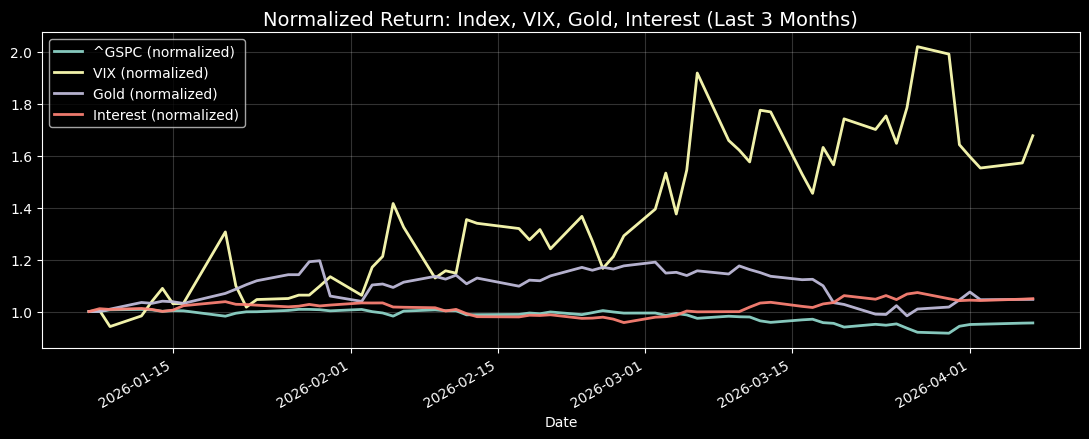

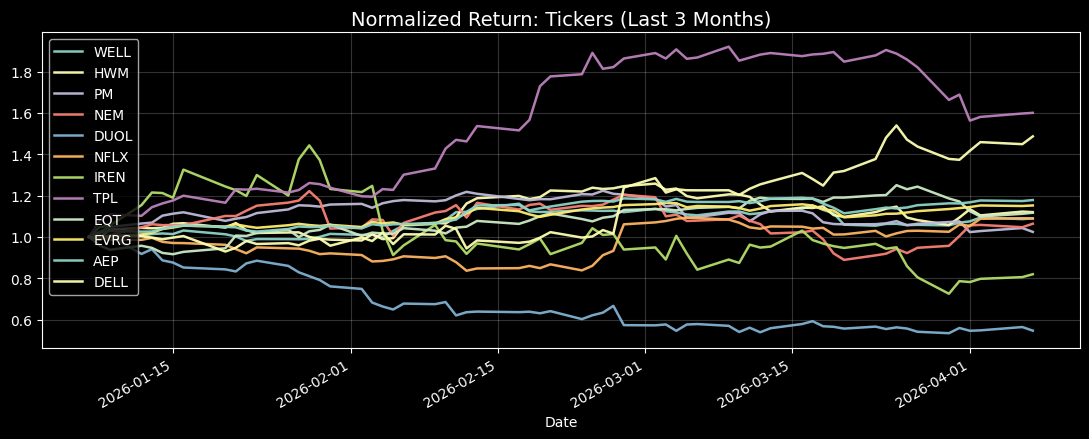

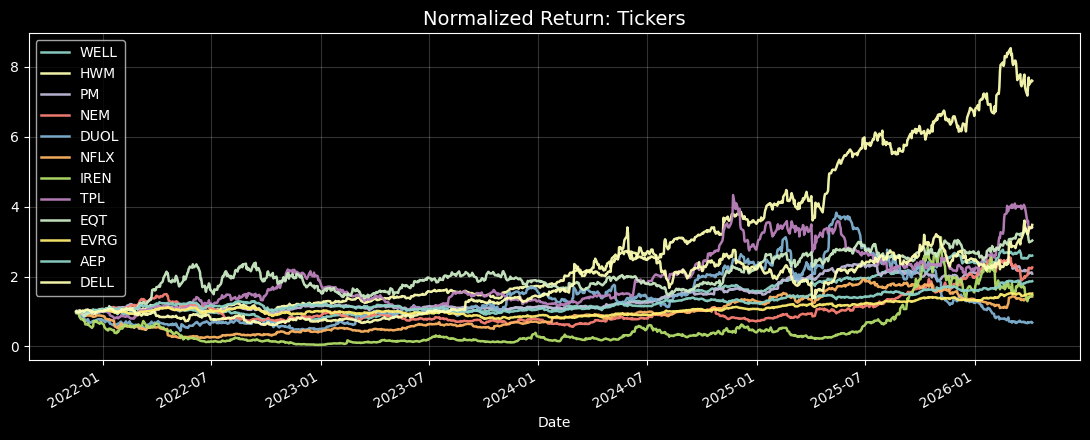

In [14]:
required_vars = [
    'normalized_returns_3m',
    'normalized_returns_tickers_3m',
    'normalized_returns',
    'plot_df'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing plotting inputs: {missing}. "
        "Run the 'Calculate Normaliezed Returns for Plot' cell first."
    )

if 'plt' not in globals():
    import matplotlib.pyplot as plt

with plt.style.context('dark_background'):
    ax = normalized_returns_3m.plot(figsize=(11, 4.5), linewidth=2.0, alpha=0.95)
    ax.set_title('Normalized Return: Index, VIX, Gold, Interest (Last 3 Months)', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

with plt.style.context('dark_background'):
    ax = normalized_returns_tickers_3m.plot(figsize=(11, 4.5), linewidth=1.8, alpha=0.95)
    ax.set_title('Normalized Return: Tickers (Last 3 Months)', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

with plt.style.context('dark_background'):
    ax = normalized_returns.plot(figsize=(11, 4.5), linewidth=1.8, alpha=0.95)
    ax.set_title('Normalized Return: Tickers', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

if SHOW_PAIRPLOT:
    with plt.style.context('dark_background'):
        pd.plotting.scatter_matrix(
            plot_df,
            figsize=(10, 10),
            diagonal='kde',
            alpha=0.45,
            marker='o',
            s=12,
            color='#1f77b4'
        )
        plt.suptitle('Pairwise Correlations of Weekly Returns (%)', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
MARKET DATA
</h3>

In [15]:
if MARKET_TABLE:
    #print('\n' + '=' * console_formating)
    print('(Annualized)'.center(console_formating))
    #print('=' * console_formating + '\n')

    summary_display = summary_df.sort_values('MC Proportion (%)', ascending=False).copy()
    for col in summary_display.columns:
        if col == 'Sector':
            summary_display[col] = summary_display[col].fillna('N/A')
        elif col in ['Market Price', '52W Low', '52W High', 'PT']:
            summary_display[col] = summary_display[col].map(lambda x: f'{round(x):.0f}' if pd.notna(x) else np.nan)
        else:
            summary_display[col] = summary_display[col].map(lambda x: f'{x:.1f}' if pd.notna(x) else np.nan)
    _print_df_with_bars(summary_display)

                                                                                    (Annualized)                                                                                    


Ticker,Sector,MC Proportion (%),Market Price,PT,ΔPT (%),52W Low,52W High,YTD Return (%),Total Return (%),Mean Return (%),σ (%),β,Sharpe Ratio,α (%)
S&P500,Index,100.0,6617,nan,nan,nan,nan,-3.5,41.1,8.2,17.6,1.0,0.5,0.0
NFLX,Communication Services,31.4,99,113,14.5,75,134,8.6,42.9,8.5,46.6,1.3,0.2,-0.9
PM,Consumer Defensive,18.7,157,190,20.5,142,191,-0.9,108.3,18.3,22.6,0.3,0.8,11.7
WELL,Real Estate,10.6,202,224,10.9,130,216,8.2,159.8,24.5,23.6,0.6,1.0,15.7
NEM,Basic Materials,9.6,115,130,13.7,46,135,13.5,126.0,20.6,38.5,0.5,0.5,12.6
DELL,Technology,9.1,178,155,-12.7,71,190,39.6,247.6,33.1,48.3,1.5,0.7,18.9
HWM,Industrials,7.5,236,267,13.2,112,267,11.5,659.4,59.3,31.6,1.1,1.9,38.1
AEP,Utilities,5.4,133,132,-0.8,97,135,15.7,86.6,15.4,20.4,0.3,0.8,9.1
EQT,Energy,2.8,61,64,5.7,45,68,13.8,202.9,29.0,42.1,0.9,0.7,17.9
TPL,Energy,2.3,450,317,-29.6,269,547,51.1,240.5,32.5,45.9,1.0,0.7,20.2


<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
FUNDAMENTALS VISUALIZATION
</h3>

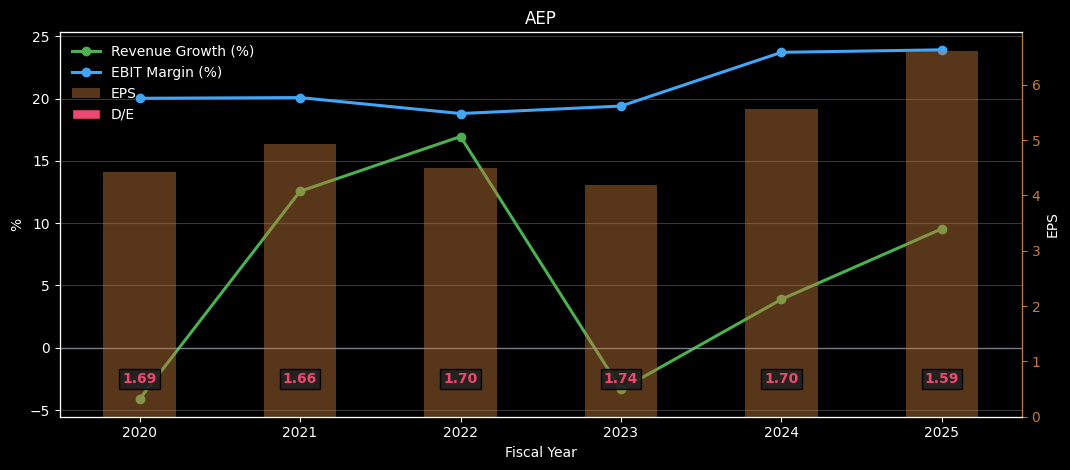

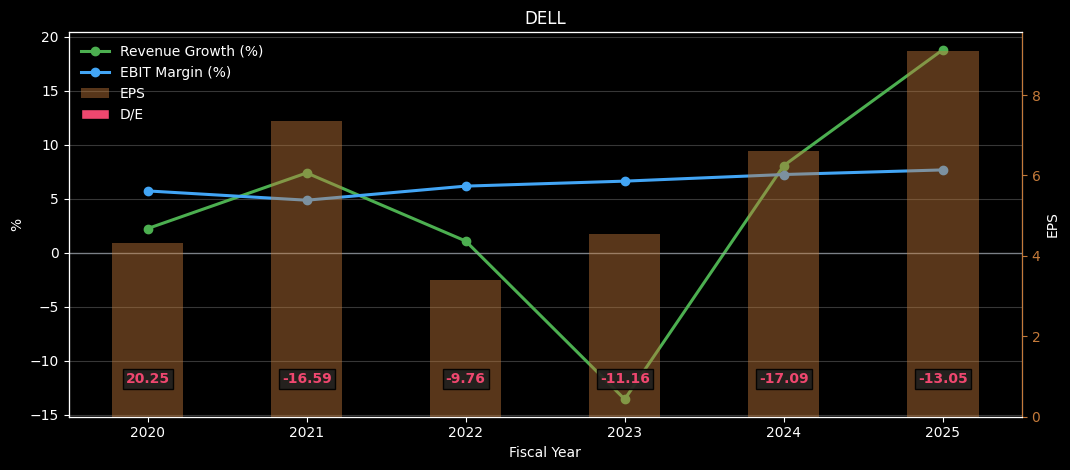

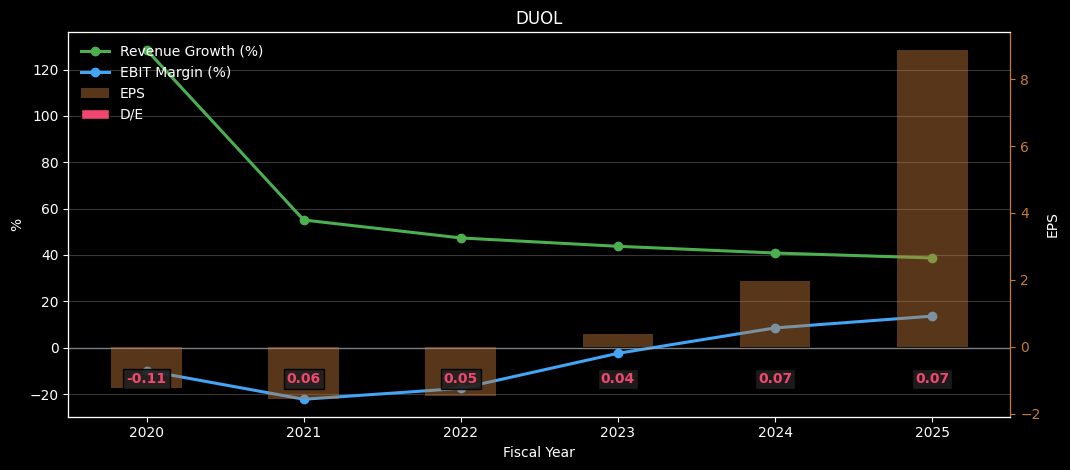

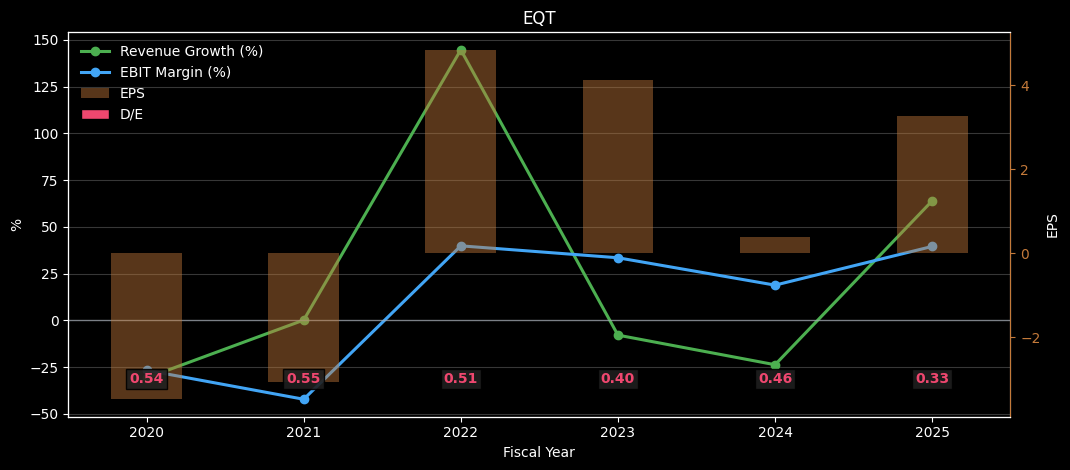

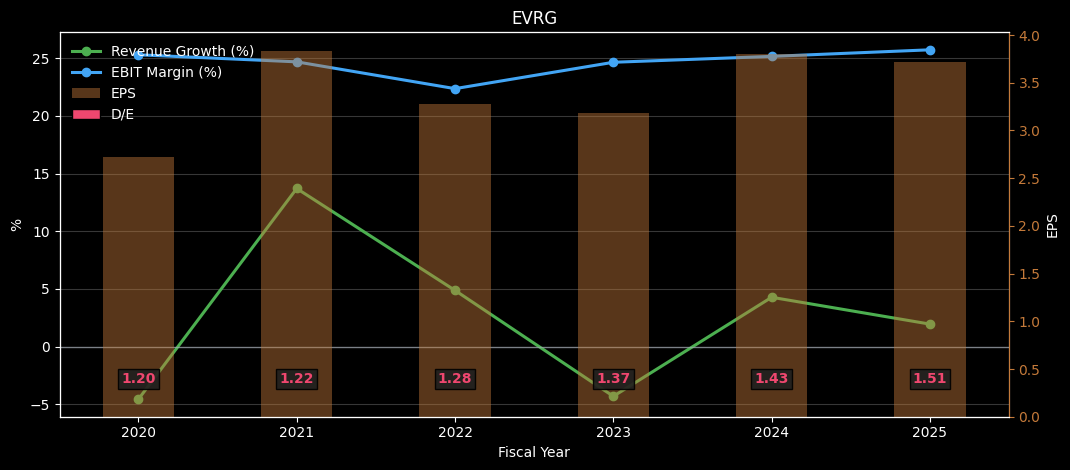

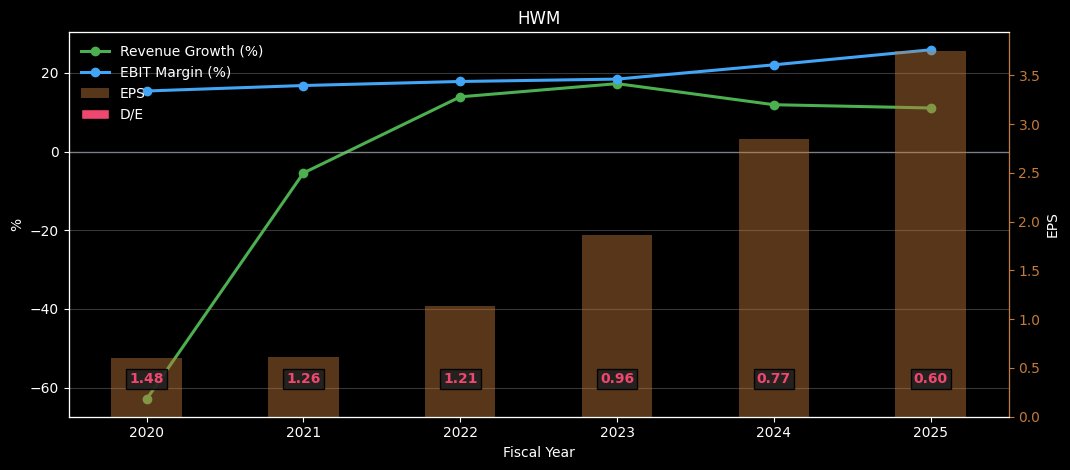

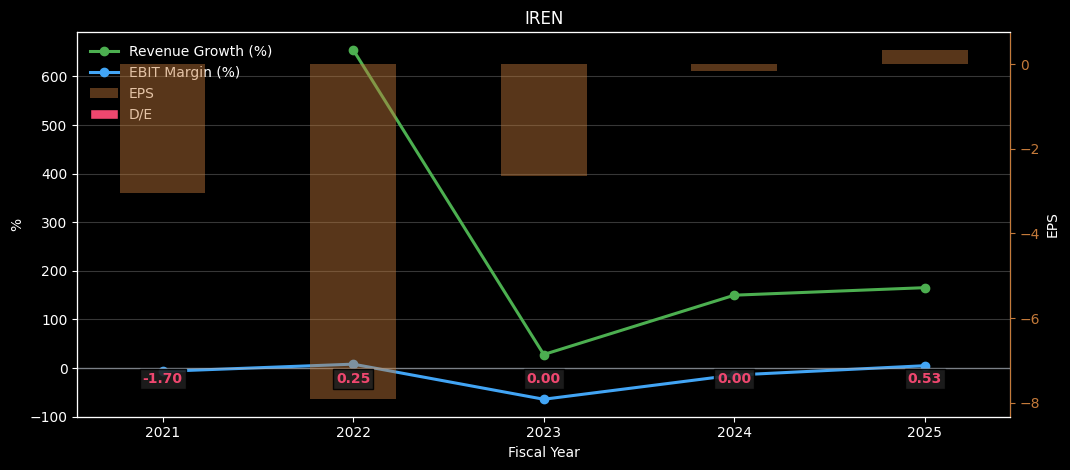

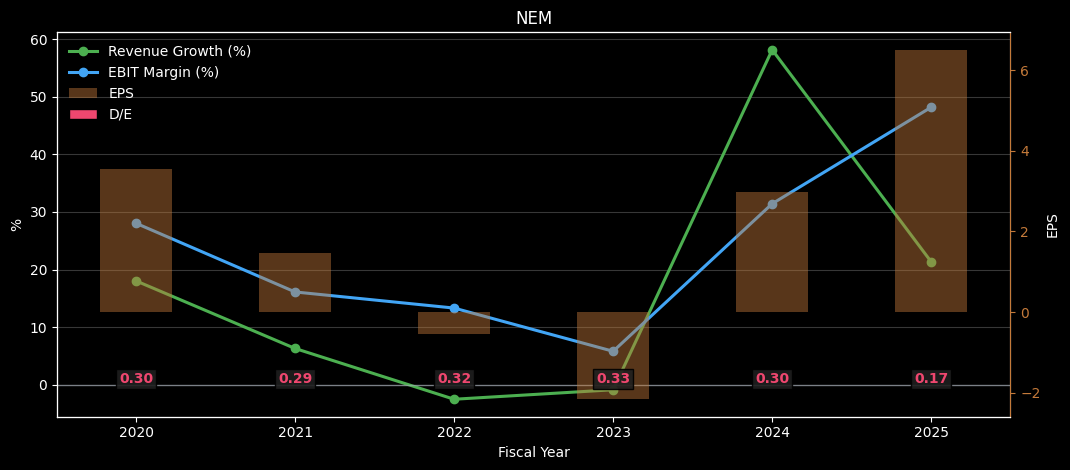

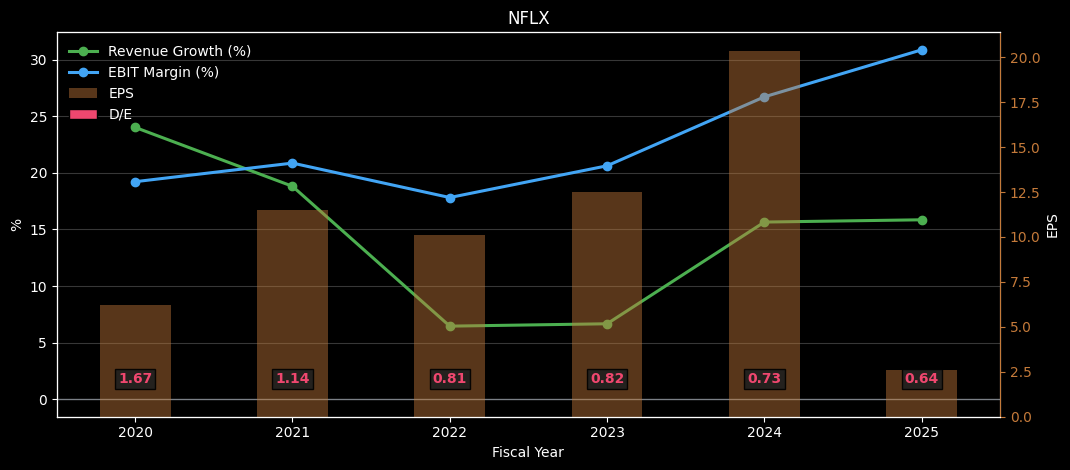

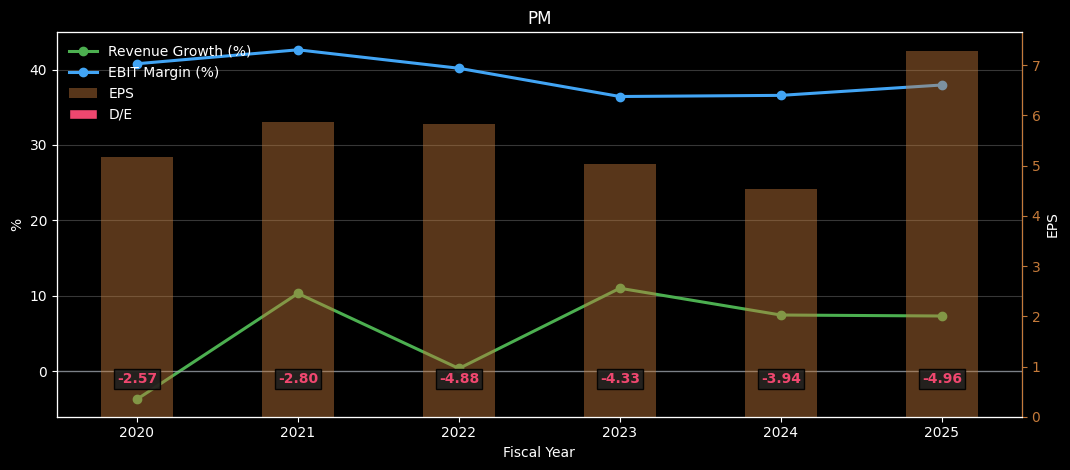

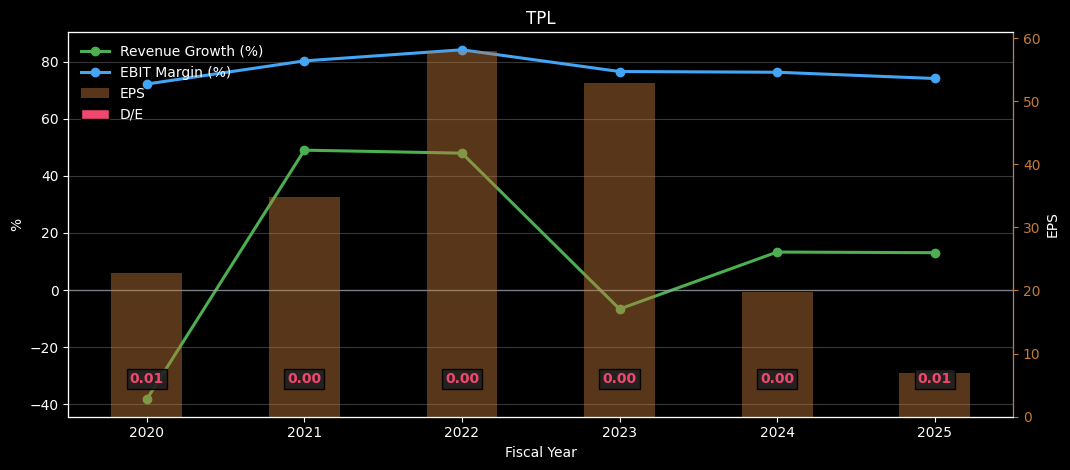

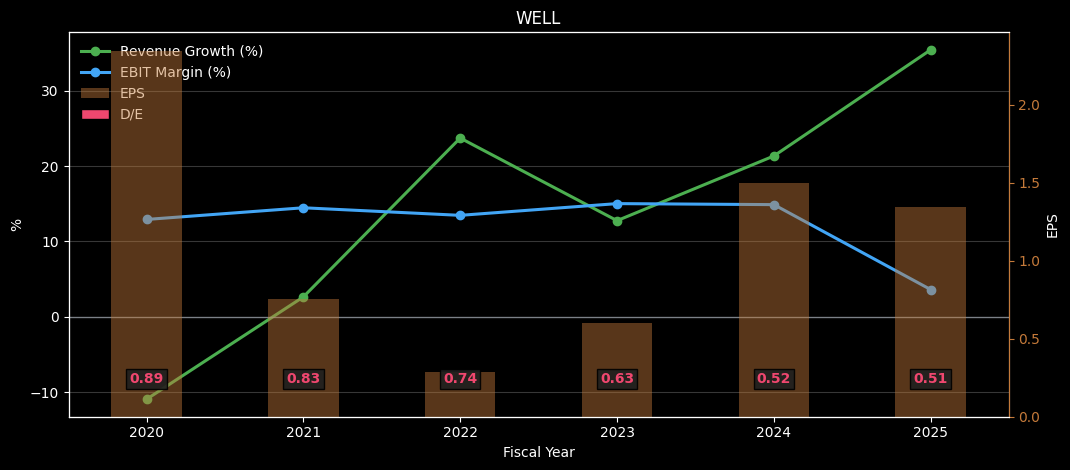

In [22]:
if FUNDAMENTALS_TABLE:
    if 'plt' not in globals():
        import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    fundamentals_plot = final.reset_index().copy()
    fundamentals_plot['fyear'] = pd.to_numeric(fundamentals_plot['fyear'], errors='coerce')

    # Dark-mode palette: revenue green, margin blue, EPS orange/brown, D/E red
    color_revenue = '#4caf50'
    color_margin = '#42a5f5'
    color_eps = '#c47a3a'
    color_de = '#ef476f'
    color_zero = '#aab2bd'

    fundamental_tickers = sorted(final.index.get_level_values(0).unique())
    for ticker in fundamental_tickers:
        tdf = fundamentals_plot[fundamentals_plot['tic'] == ticker].sort_values('fyear')
        if tdf.empty:
            continue

        years = tdf['fyear'].astype(int)
        revenue_growth_pct = tdf['Revenue_Growth'] * 100

        if 'EBITDA_Margin' in tdf.columns:
            margin_pct = tdf['EBITDA_Margin'] * 100
            margin_label = 'EBITDA Margin (%)'
        else:
            margin_pct = tdf['EBIT_Margin'] * 100
            margin_label = 'EBIT Margin (%)'

        eps_values = tdf['EPS']
        debt_to_equity = tdf['Debt_to_Equity']

        with plt.style.context('dark_background'):
            fig, ax1 = plt.subplots(figsize=(10.8, 4.8))
            fig.subplots_adjust(right=0.80)

            ax1.plot(years, revenue_growth_pct, marker='o', linewidth=2.2, color=color_revenue, label='Revenue Growth (%)')
            ax1.plot(years, margin_pct, marker='o', linewidth=2.2, color=color_margin, label=margin_label)
            ax1.axhline(0, color=color_zero, linewidth=1.0, alpha=0.6)
            ax1.set_xlabel('Fiscal Year')
            ax1.set_ylabel('%')
            ax1.grid(True, axis='y', alpha=0.22)

            ax2 = ax1.twinx()
            ax2.bar(years, eps_values, width=0.45, color=color_eps, alpha=0.45, label='EPS')
            ax2.set_ylabel('EPS')
            ax2.tick_params(axis='y', colors=color_eps)
            ax2.spines['right'].set_color(color_eps)

            ax3 = ax1.twinx()
            ax3.spines['right'].set_position(('outward', 52))
            ax3.set_ylim(0, 1)
            ax3.set_yticks([])
            ax3.tick_params(axis='y', length=0, labelright=False)
            ax3.spines['right'].set_visible(False)
            for x, value in zip(years, debt_to_equity):
                if pd.notna(value):
                    ax3.text(x, 0.08, f'{value:.2f}', ha='center', va='bottom', color=color_de, fontsize=10, fontweight='bold', transform=ax3.get_xaxis_transform(), bbox=dict(boxstyle='square,pad=0.22', facecolor='#1f1f1f', edgecolor='black', linewidth=1.0, alpha=0.9))

            lines_1, labels_1 = ax1.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            de_proxy = Patch(facecolor=color_de, edgecolor='black', label='D/E')
            ax1.legend(lines_1 + lines_2 + [de_proxy], labels_1 + labels_2 + ['D/E'], loc='upper left', frameon=False)

            plot_margin_label = margin_label.replace(' (%)', '')
            ax1.set_title(f'{ticker}')
            ax1.set_xticks(years)
            plt.tight_layout()
            plt.show()

<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
FUNDAMENTAL TABLE
</h3>

In [ ]:
if FUNDAMENTALS_TABLE:
    percent_cols = ['Revenue_Growth', 'EBIT_Margin', 'EPS_Growth', 'OCF_Growth', 'OCF_Margin']
    value_cols = ['Revenue', 'EBIT', 'EPS', 'OCF', 'Debt', 'Equity']
    fundamental_tickers = sorted(final.index.get_level_values(0).unique())
    for ticker in fundamental_tickers:
        print(f'{ticker}')
        print('--------------------------')
        fundamentals_display = final.loc[ticker].copy().sort_index(ascending=False)
        for col in percent_cols:
            fundamentals_display[col] = fundamentals_display[col].map(lambda x: f'{x:.2%}' if pd.notna(x) else np.nan)
        fundamentals_display['Debt_to_Equity'] = fundamentals_display['Debt_to_Equity'].map(lambda x: f'{x:.2f}' if pd.notna(x) else np.nan)
        for col in value_cols:
            fundamentals_display[col] = fundamentals_display[col].map(lambda x: f'{x:,.2f}' if pd.notna(x) else np.nan)
        print(fundamentals_display)
        print('\n')

AEP
--------------------------
      Revenue_Growth EBIT_Margin EPS_Growth OCF_Growth OCF_Margin Debt_to_Equity Default_Risk    Revenue      EBIT   EPS       OCF       Debt     Equity
fyear                                                                                                                                                   
2025           9.55%      23.92%     18.88%      2.05%     32.14%           1.59           Aa  21,605.50  5,167.60  6.62  6,944.00  49,663.00  31,138.00
2024           3.89%      23.72%     32.68%     35.75%     34.50%           1.70           Aa  19,721.30  4,677.10  5.57  6,804.30  45,926.40  26,943.80
2023          -3.35%      19.40%     -6.54%     -5.22%     26.40%           1.74           Aa  18,982.30  3,683.20  4.20  5,012.20  43,814.10  25,246.70
2022          16.96%      18.80%     -9.01%     37.71%     26.93%           1.70           Aa  19,639.50  3,692.70  4.49  5,288.00  40,625.70  23,893.40
2021          12.56%      20.08%     11.38%      0.

**WRDS/Compustat typically publish in USD millions**

<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
COMPS TABLE
</h3>

In [18]:
if COMPS_TABLE:
    if COMPS_SECTOR_MEDIAN_TABLE:
        _print_df_with_bars(industry_median.round(2))
        print('\n')

    comps_table_display = comps_display.sort_values(['Sector', 'Company']).copy()
    numeric_cols = comps_table_display.select_dtypes(include='number').columns
    if len(numeric_cols) > 0:
        comps_table_display[numeric_cols] = comps_table_display[numeric_cols].round(2)

    _print_df_with_bars(comps_table_display)

Company,Sector,P/E,P/E_Median,EV/Sales,EV/Sales_Median,EV/EBIT,EV/EBIT_Median,P/E_Price,EV/Sales_Price,EV/EBIT_Price
NEM,Basic Materials,18.14 (^),nan,5.92 (⌄),nan,12.28 (⌄),nan,nan,nan,nan
NFLX,Communication Services,38.39 (^),nan,9.71 (⌄),nan,31.45 (⌄),nan,nan,nan,nan
PM,Consumer Defensive,22.1 (^),nan,7.39 (^),nan,19.47 (^),nan,nan,nan,nan
EQT,Energy,18.42 (⌄),nan,5.26 (⌄),nan,13.3 (⌄),nan,nan,nan,nan
TPL,Energy,64.2 (^),nan,38.74 (^),nan,52.22 (^),nan,nan,nan,nan
IREN,Financial Services,140.54 (^),nan,26.31 (^),nan,539.47 (⌄),nan,nan,nan,nan
HWM,Industrials,66.47 (⌄),nan,12.54 (⌄),nan,48.5 (⌄),nan,nan,nan,nan
WELL,Real Estate,152.46 (⌄),nan,15.17 (^),nan,420.53 (⌄),nan,nan,nan,nan
DELL,Technology,20.71 (^),nan,1.37 (⌄),nan,17.8 (⌄),nan,nan,nan,nan
DUOL,Technology,10.33 (⌄),nan,4.22 (^),nan,30.99 (^),nan,nan,nan,nan


<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
PORTFOLIO OPTIMIZATION
</h3>

In [19]:
if PORTFOLIO_TABLE:
    _print_df_with_bars(combined_portfolio_df)

Index,Min Variance,Tangent,Min Correlation,Max Return
E[R],18.34 %,31.03 %,16.32 %,38.45 %
σ,15.28 %,17.19 %,26.80 %,29.71 %
Variance,0.02,0.03,0.07,0.09
Sharpe Ratio,1.20,1.80,0.61,1.29
,---,---,---,---
WELL,9.55 %,20.24 %,2.38 %,0.00 %
HWM,4.30 %,25.00 %,0.00 %,25.00 %
PM,25.00 %,22.41 %,14.71 %,0.00 %
NEM,2.80 %,3.43 %,9.33 %,0.00 %
DUOL,1.44 %,0.00 %,12.28 %,0.00 %


***P/E, EV/Sales, EV/EBIT - Company multiples compared to sector median**

***P/E_Price, EV/Sales_Price, EV/EBIT_Price - Comps implied price compared to company market price**

***P/E_Median, EV/Sales_Median, EV/EBIT_Median - Company historical median multiple value (Jan 1 of last year to today)**

<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
MACRO FACTOR CORRELATION
</h3>

In [20]:
if MACRO_TABLE:
    if not correlation_macro.empty:
        macro_ytd = {}
        for macro in macro_factors:
            series = df_macro_prices['Adj Close'][macro]
            start_price = _get_price_on_or_after(series, start_of_year)
            ytd_change = (series.iloc[-1] / start_price) - 1
            macro_ytd[macro] = ytd_change * 100

        macro_ytd_formatted = {
            'VIX': f"{macro_ytd['^VIX']:+.2f}%",
            'Gold': f"{macro_ytd['GC=F']:+.2f}%",
            'Interest': f"{macro_ytd['^TNX']:+.2f}%"
        }

        change_row = pd.DataFrame([macro_ytd_formatted], index=['CHANGE'])
        separator_row = pd.DataFrame([['---', '---', '---']], columns=['VIX', 'Gold', 'Interest'], index=[''])
        macro_table = pd.concat([change_row, separator_row, correlation_macro.round(2)])
        _print_df_with_bars(macro_table)
    else:
        print('No macro data available to compute correlations.')

<h3 style="color: #ff8c00; font-size: 2em; font-weight: bold; border-bottom: 2px solid #ff8c00; padding-bottom: 5px;">
OPTIMAL TICKERS FILTER
</h3>

In [21]:
TOP_PERCENTILE = 0.50

def _percentile_score_high(series):
    s = pd.to_numeric(series, errors='coerce')
    if s.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)
    return s.rank(method='average', pct=True).fillna(0.0)


def _percentile_score_low(series):
    s = pd.to_numeric(series, errors='coerce')
    if s.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)
    return (-s).rank(method='average', pct=True).fillna(0.0)


def _top_count(n_items, top_percentile=TOP_PERCENTILE):
    return max(1, int(np.ceil(n_items * top_percentile)))



if TICKERS_FILTER:
    fundamentals_latest = latest_fundamentals.set_index('tic')

    market_df = summary_df.loc[stock_tickers].copy()
    market_df['Score_Return'] = _percentile_score_high(market_df['Mean Return (%)'])
    market_df['Score_Sharpe'] = _percentile_score_high(market_df['Sharpe Ratio'])
    market_df['Score_Alpha'] = _percentile_score_high(market_df['α (%)'])
    market_df['Score_Upside'] = _percentile_score_high(market_df['ΔPT (%)'])

    market_df['Market_Score'] = (
        0.30 * market_df['Score_Return']
        + 0.25 * market_df['Score_Sharpe']
        + 0.25 * market_df['Score_Alpha']
        + 0.20 * market_df['Score_Upside']
    )

    cutoff_market = _top_count(len(market_df), TOP_PERCENTILE)
    top_market = market_df.sort_values('Market_Score', ascending=False).head(cutoff_market)
    top_market_tickers = top_market.index.tolist()

    print(f'Top Market Analysis ({int(TOP_PERCENTILE * 100)}%):')
    print(top_market_tickers)
    print('\n')

    comps_filter_df = comps_numeric.loc[comps_numeric.index.intersection(top_market_tickers)].copy()
    comps_scores = []

    for ticker in comps_filter_df.index:
        row = comps_filter_df.loc[ticker]
        sector = row['Sector']

        if sector not in industry_median.index:
            continue

        sector_med = industry_median.loc[sector]
        pe = row['P/E']
        eps_growth = fundamentals_latest.loc[ticker]['EPS_Growth']
        ev_sales = row['EV/Sales']
        sector_ev_sales = sector_med['EV/Sales']

        peg = np.nan
        if pd.notna(pe) and pd.notna(eps_growth) and eps_growth != 0:
            peg = pe / (eps_growth * 100)

        ev_sales_relative = np.nan
        if pd.notna(ev_sales) and pd.notna(sector_ev_sales) and sector_ev_sales != 0:
            ev_sales_relative = ev_sales / sector_ev_sales

        comps_scores.append({
            'Ticker': ticker,
            'PEG': peg,
            'EV_Sales_Relative': ev_sales_relative
        })

    if len(comps_scores) > 0:
        comps_scores_df = pd.DataFrame(comps_scores).set_index('Ticker')
        comps_scores_df['Score_PEG'] = _percentile_score_low(comps_scores_df['PEG'])
        comps_scores_df['Score_EVSalesRel'] = _percentile_score_low(comps_scores_df['EV_Sales_Relative'])
        comps_scores_df['Score'] = 0.55 * comps_scores_df['Score_PEG'] + 0.45 * comps_scores_df['Score_EVSalesRel']
        cutoff_comps = _top_count(len(comps_scores_df), TOP_PERCENTILE)
        top_comps = comps_scores_df.sort_values('Score', ascending=False).head(cutoff_comps)
        top_comps_tickers = top_comps.index.tolist()
    else:
        top_comps_tickers = []

    print(f'Top COMPS ({int(TOP_PERCENTILE * 100)}% of Market Filter):')
    print(top_comps_tickers)
    print('\n')

    fundamentals_filter = fundamentals_latest.loc[fundamentals_latest.index.intersection(top_comps_tickers)].copy()
    if not fundamentals_filter.empty:
        fundamentals_filter = fundamentals_filter.join(market_df[['Market_Score']], how='left')
        fundamentals_filter['Score_RevenueGrowth'] = _percentile_score_high(fundamentals_filter['Revenue_Growth'])
        fundamentals_filter['Score_EPSGrowth'] = _percentile_score_high(fundamentals_filter['EPS_Growth'])
        fundamentals_filter['Score_OCFGrowth'] = _percentile_score_high(fundamentals_filter['OCF_Growth'])
        fundamentals_filter['Score_EBITMargin'] = _percentile_score_high(fundamentals_filter['EBIT_Margin'])
        fundamentals_filter['Score_DebtToEquity'] = _percentile_score_low(fundamentals_filter['Debt_to_Equity'])
        fundamentals_filter['Score_Market'] = _percentile_score_high(fundamentals_filter['Market_Score'])

        fundamentals_filter['Fundamental_Score'] = (
            0.20 * fundamentals_filter['Score_RevenueGrowth']
            + 0.22 * fundamentals_filter['Score_EPSGrowth']
            + 0.18 * fundamentals_filter['Score_OCFGrowth']
            + 0.20 * fundamentals_filter['Score_EBITMargin']
            + 0.10 * fundamentals_filter['Score_DebtToEquity']
            + 0.10 * fundamentals_filter['Score_Market']
        )

        cutoff_fundamentals = _top_count(len(fundamentals_filter), TOP_PERCENTILE)
        top_fundamentals = fundamentals_filter.sort_values('Fundamental_Score', ascending=False).head(cutoff_fundamentals)
        top_fundamental_tickers = top_fundamentals.index.tolist()
    else:
        top_fundamental_tickers = []

    print(f'Top Fundamentals ({int(TOP_PERCENTILE * 100)}% from Market+COMPS):')
    print(top_fundamental_tickers)
    print('\n')

Top Market Analysis (50%):
['HWM', 'WELL', 'TPL', 'PM', 'EQT', 'DELL']


Top COMPS (50% of Market Filter):
['EQT', 'WELL', 'DELL']


Top Fundamentals (50% from Market+COMPS):
['EQT', 'DELL']


